# Dispersion Relations and Band Gaps — From First Principles

This notebook teaches dispersion physics from the ground up, using the same
parameters as the PINN impact-damper chain (n_dof = 5, mx = 1, my = 0.3, K = 1).

**No PINN or TensorFlow needed** — Sections 1–3 and 5 are purely analytical.

| Section | Topic |
|---------|-------|
| 1 | What is a dispersion relation? (monoatomic chain) |
| 2 | Add an internal mass: the mass-in-mass chain |
| 3 | Impacts as an effective spring — band gap physics |
| 4 | Full comparison: linear vs mass-in-mass vs PINN |
| 5 | Group velocity and wave propagation speed |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

from dispersion_theory import (
    monoatomic_dispersion,
    mass_in_mass_dispersion,
    band_gap_edges,
    resonance_freq,
    estimate_k_int,
    group_velocity,
)

# ── shared system parameters (same as PINN simulation) ──────────────────────
K      = 1.0    # inter-cell coupling spring stiffness
mx     = 1.0    # primary (outer) mass
my     = 0.3    # internal (inner) mass
k_int_example = 8.6483   # example effective spring (will be estimated from PINN later)

k_vals = np.linspace(0, np.pi, 1000)   # Brillouin zone: [0, π] rad/unit-cell

FS = 13   # base font size
plt.rcParams.update({'font.size': FS})
print('Setup complete.')

Setup complete.


---
## Section 1 — What is a Dispersion Relation?

A **dispersion relation** ω(k) maps:
- **k** = wavenumber = spatial frequency (rad per unit-cell), ranging from 0 to π in the first Brillouin zone
- **ω** = angular frequency = temporal frequency (rad/s)

For a **monoatomic chain** (beads of mass mx connected by springs K):

$$\omega(k) = 2\sqrt{\frac{K}{m_x}}\,\left|\sin\!\left(\frac{k}{2}\right)\right|$$

Key features:
- **k = 0**: ω = 0 — all beads move in phase, no deformation, no restoring force
- **k = π**: ω = ω_max = 2√(K/mx) — alternating motion, maximum compression
- **Slope at k = 0** = group velocity of long-wavelength sound waves = √(K/mx) · lattice_constant
- This chain has **one branch** → one mode per wavevector → no band gap

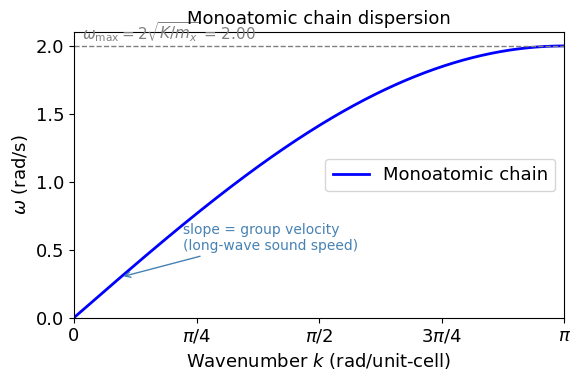

omega_max (monoatomic) = 2.0000 rad/s


In [2]:
omega_mono = monoatomic_dispersion(k_vals, K, mx)
omega_max_lin = 2.0 * np.sqrt(K / mx)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(k_vals, omega_mono, 'b-', lw=2, label='Monoatomic chain')

# Annotations
ax.axhline(omega_max_lin, ls='--', color='gray', lw=1)
ax.text(0.05, omega_max_lin + 0.05, r'$\omega_{\max}=2\sqrt{K/m_x}$'+f' = {omega_max_lin:.2f}',
        fontsize=11, color='gray')
ax.annotate('slope = group velocity\n(long-wave sound speed)',
            xy=(0.3, monoatomic_dispersion(0.3, K, mx)),
            xytext=(0.7, 0.5),
            arrowprops=dict(arrowstyle='->', color='steelblue'),
            fontsize=10, color='steelblue')

ax.set_xlabel(r'Wavenumber $k$ (rad/unit-cell)', fontsize=FS)
ax.set_ylabel(r'$\omega$ (rad/s)', fontsize=FS)
ax.set_title('Monoatomic chain dispersion', fontsize=FS)
ax.set_xlim(0, np.pi)
ax.set_ylim(0, None)
ax.xaxis.set_ticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
ax.xaxis.set_ticklabels(['0', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$'])
ax.legend()
plt.tight_layout()
plt.show()
print(f'omega_max (monoatomic) = {omega_max_lin:.4f} rad/s')

**Reading the dispersion curve:**
- Any wave with frequency ω < ω_max **propagates** through the chain
- Any excitation at ω > ω_max **does not propagate** — the chain acts as a low-pass filter
- The curve is a **single branch**: there is no band gap inside [0, ω_max]

---
## Section 2 — Add an Internal Mass: the Mass-in-Mass Chain

Now each unit cell contains:
- An **outer mass** mx, coupled to neighbours by springs K
- An **inner mass** my, attached to mx by a local spring k_int

Equations of motion (Bloch-reduced, k = wavenumber):

$$\begin{pmatrix} K_b + k_{\rm int} - \omega^2 m_x & -k_{\rm int} \\ -k_{\rm int} & k_{\rm int} - \omega^2 m_y \end{pmatrix} \begin{pmatrix} X \\ Y \end{pmatrix} = 0$$

where $K_b(k) = 2K(1-\cos k)$ is the Bloch stiffness.

Setting det = 0 gives a **quadratic in ω²**:

$$m_x m_y\,\omega^4 - [k_{\rm int}\,m_x + (K_b + k_{\rm int})\,m_y]\,\omega^2 + K_b\,k_{\rm int} = 0$$

Two roots → **two branches**: acoustic (lower) and optical (upper).
The gap between them is the **band gap** — no waves propagate there.

5.369140216707575 6.121761729001438


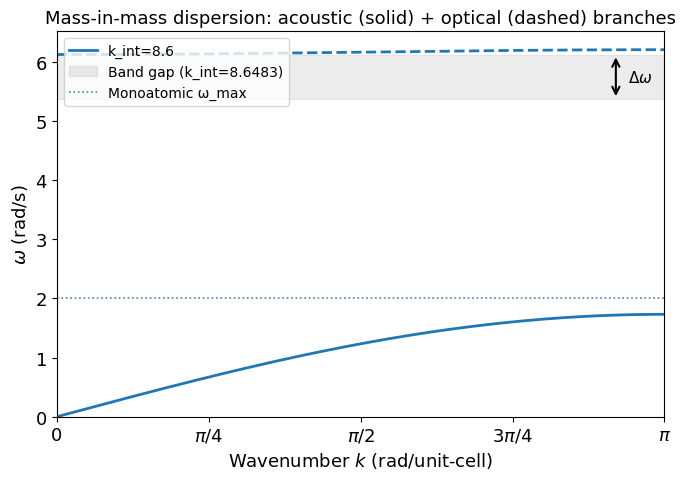

In [15]:
# Plot both branches for k_int values
k_int_values = [8.6483]
colors = ['#1f77b4']
fig, ax = plt.subplots(figsize=(7, 5))

for ki, col in zip(k_int_values, colors):
    om_lo, om_hi = mass_in_mass_dispersion(k_vals, K, mx, my, ki)
    gap_lo, gap_hi = band_gap_edges(K, mx, my, ki)
    ax.plot(k_vals, om_lo, '-',  color=col, lw=2,   label=f'k_int={ki:.1f}')
    ax.plot(k_vals, om_hi, '--', color=col, lw=2)
    # shade band gap at the rightmost k_int for illustration

# Shade band gap for the example value
gap_lo, gap_hi = band_gap_edges(K, mx, my, k_int_example)
print(gap_lo, gap_hi)
ax.axhspan(gap_lo, gap_hi, color='gray', alpha=0.15, label=f'Band gap (k_int={k_int_example})')
ax.annotate('', xy=(np.pi*0.92, gap_hi), xytext=(np.pi*0.92, gap_lo),
            arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax.text(np.pi*0.94, (gap_lo+gap_hi)/2, r'$\Delta\omega$', fontsize=11, va='center')

ax.axhline(omega_max_lin, ls=':', color='steelblue', lw=1.2, label='Monoatomic ω_max')
ax.set_xlabel(r'Wavenumber $k$ (rad/unit-cell)', fontsize=FS)
ax.set_ylabel(r'$\omega$ (rad/s)', fontsize=FS)
ax.set_title('Mass-in-mass dispersion: acoustic (solid) + optical (dashed) branches', fontsize=FS)
ax.set_xlim(0, np.pi)
ax.set_ylim(0, None)
ax.xaxis.set_ticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
ax.xaxis.set_ticklabels(['0', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$'])
ax.legend(fontsize=10, loc='upper left')
plt.tight_layout()
plt.show()

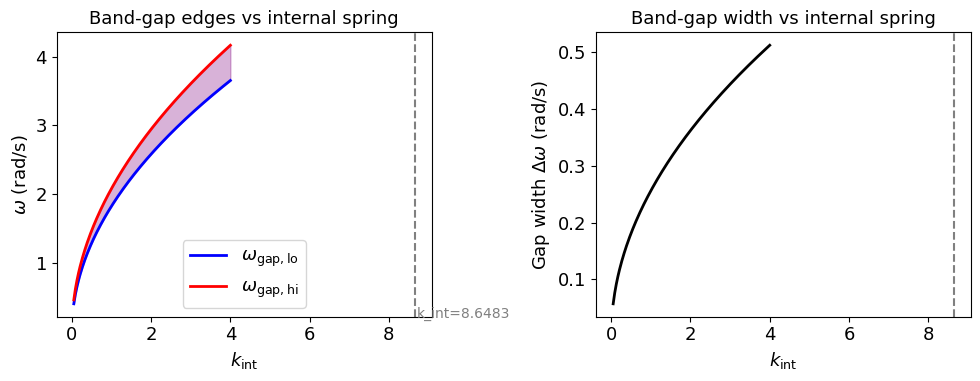

For k_int = 8.6483: gap = [5.369, 6.122] rad/s, width = 0.753


In [4]:
# How does the band-gap width vary with k_int?
k_int_scan = np.linspace(0.05, 4.0, 200)
gap_lo_arr = np.array([band_gap_edges(K, mx, my, ki)[0] for ki in k_int_scan])
gap_hi_arr = np.array([band_gap_edges(K, mx, my, ki)[1] for ki in k_int_scan])
gap_width  = gap_hi_arr - gap_lo_arr

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].fill_between(k_int_scan, gap_lo_arr, gap_hi_arr, alpha=0.3, color='purple')
axes[0].plot(k_int_scan, gap_lo_arr, 'b-', lw=2, label=r'$\omega_{\rm gap,lo}$')
axes[0].plot(k_int_scan, gap_hi_arr, 'r-', lw=2, label=r'$\omega_{\rm gap,hi}$')
axes[0].axvline(k_int_example, ls='--', color='gray')
axes[0].text(k_int_example+0.05, 0.2, f'k_int={k_int_example}', fontsize=10, color='gray')
axes[0].set_xlabel(r'$k_{\rm int}$', fontsize=FS)
axes[0].set_ylabel(r'$\omega$ (rad/s)', fontsize=FS)
axes[0].set_title('Band-gap edges vs internal spring', fontsize=FS)
axes[0].legend()

axes[1].plot(k_int_scan, gap_width, 'k-', lw=2)
axes[1].axvline(k_int_example, ls='--', color='gray')
axes[1].set_xlabel(r'$k_{\rm int}$', fontsize=FS)
axes[1].set_ylabel(r'Gap width $\Delta\omega$ (rad/s)', fontsize=FS)
axes[1].set_title('Band-gap width vs internal spring', fontsize=FS)

plt.tight_layout()
plt.show()

gap_lo, gap_hi = band_gap_edges(K, mx, my, k_int_example)
print(f'For k_int = {k_int_example}: gap = [{gap_lo:.3f}, {gap_hi:.3f}] rad/s, width = {gap_hi-gap_lo:.3f}')

**Why does the band gap appear?**

1. **Anti-crossing / avoided crossing**: The acoustic branch (which would continue rising like the monoatomic chain) encounters the internal resonance frequency ω_res = √(k_int / my). The two modes repel each other, splitting into acoustic (below gap) and optical (above gap).

2. **Energy storage**: Near ω_res, energy pumped into the outer mass is immediately transferred to the inner mass, which oscillates at 180° out of phase. The outer mass barely moves → wave cannot propagate → gap.

3. **Gap edges**:
   - Lower edge = ω_res = √(k_int / my)  ← pure internal resonance (K_b → 0)
   - Upper edge = √(k_int(mx+my)/(mx·my)) ← both masses oscillate against each other

**Wider k_int → higher resonance frequency + wider gap.**

---
## Section 3 — Impacts as an Effective Spring

In the PINN impact-damper model, there is **no linear spring** between mx and my.
Instead, the masses interact through **impacts** (nonlinear, impulsive forces).

**Key insight**: repeated impacts act like a *time-averaged* linear spring.
If the dominant frequency of the impact sequence is ω₀, then the effective spring is:

$$k_{\rm int,eff} \approx m_y \cdot \omega_0^2$$

This is the inverse of the resonance formula: ω_res = √(k_int / my).

**Consequences for the dispersion curve:**
- The PINN spectrum shows a **flat band** at ω₀ — a k-independent mode (local resonance)
- A **band gap** opens between the acoustic branch and the flat band
- Above ω₀, the optical branch resumes — but at higher harmonics (2ω₀, 3ω₀, ...) because the impacts are periodic and nonlinear

Flat band observed at omega_0 = 5.369 rad/s
Effective spring  k_int_eff   = 8.6478
Check resonance   omega_res   = 5.3690 rad/s  (should match omega_0)
Analytical gap    [5.369, 6.122] rad/s   width = 0.753


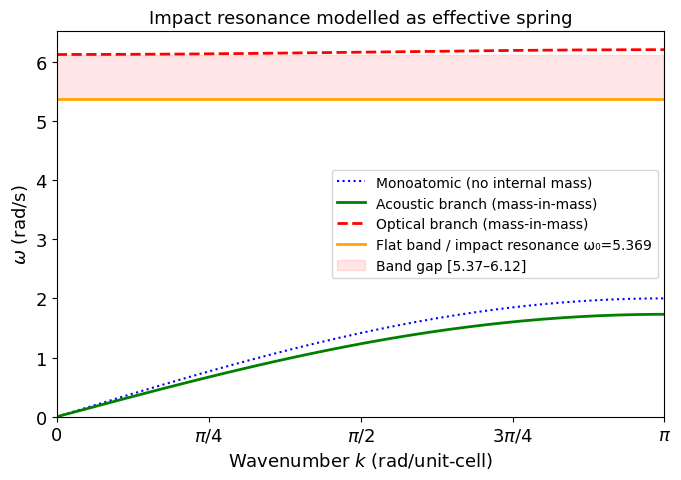

In [5]:
# Suppose the PINN flat band is observed at omega_0
omega_0 = 5.369   # example — replace with value read from your PINN DOS peak

k_int_eff = estimate_k_int(omega_0, my)
omega_res = resonance_freq(k_int_eff, my)
gap_lo, gap_hi = band_gap_edges(K, mx, my, k_int_eff)

print(f'Flat band observed at omega_0 = {omega_0:.3f} rad/s')
print(f'Effective spring  k_int_eff   = {k_int_eff:.4f}')
print(f'Check resonance   omega_res   = {omega_res:.4f} rad/s  (should match omega_0)')
print(f'Analytical gap    [{gap_lo:.3f}, {gap_hi:.3f}] rad/s   width = {gap_hi-gap_lo:.3f}')

# Plot: monoatomic + mass-in-mass overlay
omega_mono  = monoatomic_dispersion(k_vals, K, mx)
om_lo, om_hi = mass_in_mass_dispersion(k_vals, K, mx, my, k_int_eff)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(k_vals, omega_mono, 'b:', lw=1.5, label='Monoatomic (no internal mass)')
ax.plot(k_vals, om_lo,  'g-',  lw=2,   label='Acoustic branch (mass-in-mass)')
ax.plot(k_vals, om_hi,  'r--', lw=2,   label='Optical branch (mass-in-mass)')
ax.axhline(omega_0, color='orange', ls='-', lw=2, label=f'Flat band / impact resonance ω₀={omega_0}')
ax.axhspan(gap_lo, gap_hi, color='red', alpha=0.1, label=f'Band gap [{gap_lo:.2f}–{gap_hi:.2f}]')

ax.set_xlabel(r'Wavenumber $k$ (rad/unit-cell)', fontsize=FS)
ax.set_ylabel(r'$\omega$ (rad/s)', fontsize=FS)
ax.set_title('Impact resonance modelled as effective spring', fontsize=FS)
ax.set_xlim(0, np.pi)
ax.set_ylim(0, None)
ax.xaxis.set_ticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
ax.xaxis.set_ticklabels(['0', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$'])
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

**Why flat bands appear in the PINN spectrum:**
- A flat band means ω is the same for all k → the mode is **localized** (does not propagate)
- This is the internal mass oscillating independently of its neighbours
- In the PINN, the impact force excites this mode at ω₀; it appears as a bright horizontal stripe in the S(k,ω) heatmap

**Why multiple flat bands appear:**
- Impacts are nonlinear → they generate harmonics: 2ω₀, 3ω₀, ...
- Each harmonic shows up as an additional flat (or nearly flat) band at higher frequency
- The gaps between harmonics are regions where no energy was injected → band gaps in the PINN result

---
## Section 4 — Full Comparison: Linear vs Mass-in-Mass vs PINN

This section overlays the analytical dispersion on the PINN spectrum heatmap.
If `pinn_results.mat` does not exist, it plots only the analytical curves.

Loaded  pinn_results.mat
  t_total      : (50050,),  span 0.000 – 13.740 s
  x_PINN_total : (50050, 20)
  params       : ['n_dof', 'mx', 'my', 'k', 'c', 'D', 'r', 'phi1', 'phi2']
PINN data loaded from pinn_results.mat
  uniform grid: 263 pts,  ω_Nyq = 60.00 rad/s


/var/folders/qq/0y83lt2x4z78hjpkv8jj_yh00000gn/T/ipykernel_27354/3620415991.py:46: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax.pcolormesh(k_c, omega_c, S_dB.T, cmap='inferno', vmin=-40, shading='auto')


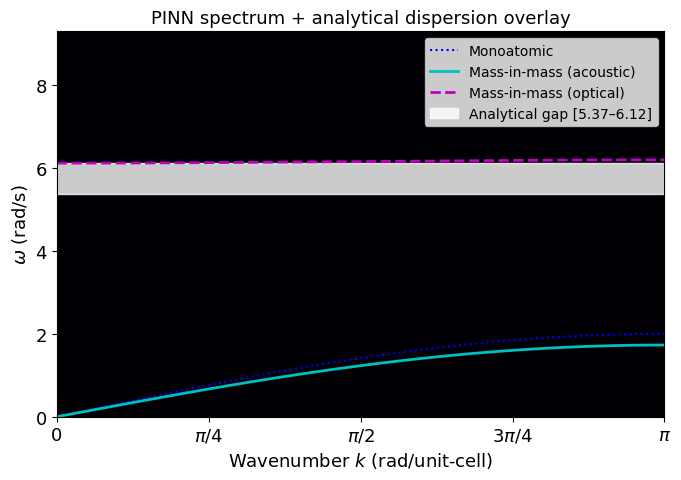

In [11]:
import glob as _glob

# ── Try to load PINN results ─────────────────────────────────────────────────
mat_files = _glob.glob('../PINN_ndofs_nmasses/pinn_results*.mat') + \
            _glob.glob('pinn_results*.mat')

pinn_available = False
if mat_files:
    try:
        from pinn_dispersion_from_mat import (
            load_pinn_results, resample_to_uniform, dispersion_from_2dfft
        )
        t_raw, x_raw, pinn_params = load_pinn_results(mat_files[0])
        # x_raw: (T, n_dof) → transpose to (n_dof, T) for resample/FFT
        X_raw = x_raw.T

        # Resample to a coarser uniform grid that resolves up to 4×ω_max_lin
        # (without this, Nyquist ≈ 11 000 rad/s and the spectrum is 99.9% empty)
        omega_max_lin_pinn = 2.0 * np.sqrt(K / mx)
        t_unif, X_unif, _, _ = resample_to_uniform(t_raw, X_raw, omega_max_lin_pinn,
                                                    n_harmonic=6, pts_per_cycle=10)
        k_c, omega_c, spectrum = dispersion_from_2dfft(t_unif, X_unif)
        pinn_available = True
        print(f'PINN data loaded from {mat_files[0]}')
        print(f'  uniform grid: {X_unif.shape[1]} pts,  '
              f'ω_Nyq = {np.pi / (t_unif[1]-t_unif[0]):.2f} rad/s')
    except Exception as e:
        print(f'Could not load PINN data: {e}\nRunning analytical-only mode.')
        import traceback; traceback.print_exc()
else:
    print('No pinn_results.mat found — showing analytical curves only.')

# ── Analytical curves ────────────────────────────────────────────────────────
omega_mono   = monoatomic_dispersion(k_vals, K, mx)
om_lo, om_hi = mass_in_mass_dispersion(k_vals, K, mx, my, k_int_eff)
gap_lo, gap_hi = band_gap_edges(K, mx, my, k_int_eff)

# Display up to 1.5× the optical branch ceiling (or at least 3× ω_max_lin)
omega_disp_max = max(om_hi.max() * 1.5, 3.0 * 2.0 * np.sqrt(K / mx))

fig, ax = plt.subplots(figsize=(7, 5))

if pinn_available:
    S_dB = 10 * np.log10(spectrum + 1e-12)
    S_dB -= S_dB.max()
    ax.pcolormesh(k_c, omega_c, S_dB.T, cmap='inferno', vmin=-40, shading='auto')

ax.plot(k_vals, omega_mono, 'b:',  lw=1.5, label='Monoatomic')
ax.plot(k_vals, om_lo,      'c-',  lw=2,   label='Mass-in-mass (acoustic)')
ax.plot(k_vals, om_hi,      'm--', lw=2,   label='Mass-in-mass (optical)')
ax.axhspan(gap_lo, gap_hi, color='white', alpha=0.8,
           label=f'Analytical gap [{gap_lo:.2f}–{gap_hi:.2f}]')

ax.set_xlabel(r'Wavenumber $k$ (rad/unit-cell)', fontsize=FS)
ax.set_ylabel(r'$\omega$ (rad/s)', fontsize=FS)
ax.set_title('PINN spectrum + analytical dispersion overlay', fontsize=FS)
ax.set_xlim(0, np.pi)
ax.set_ylim(0, omega_disp_max)
ax.xaxis.set_ticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
ax.xaxis.set_ticklabels(['0', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$'])
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## Section 5 — Group Velocity and Wave Propagation Speed

The **group velocity** v_g = dω/dk is the speed at which energy (and information) travels:

- **v_g > 0**: wave propagates forward
- **v_g = 0**: standing wave — energy does not move (band edge, flat band)
- Inside the band gap: no real wave exists → v_g is undefined

At k = 0 (long wavelength), the acoustic branch has v_g = √(K/mx) (lattice units).
Near the band-gap edge, v_g → 0 — waves slow to a halt and reflect.

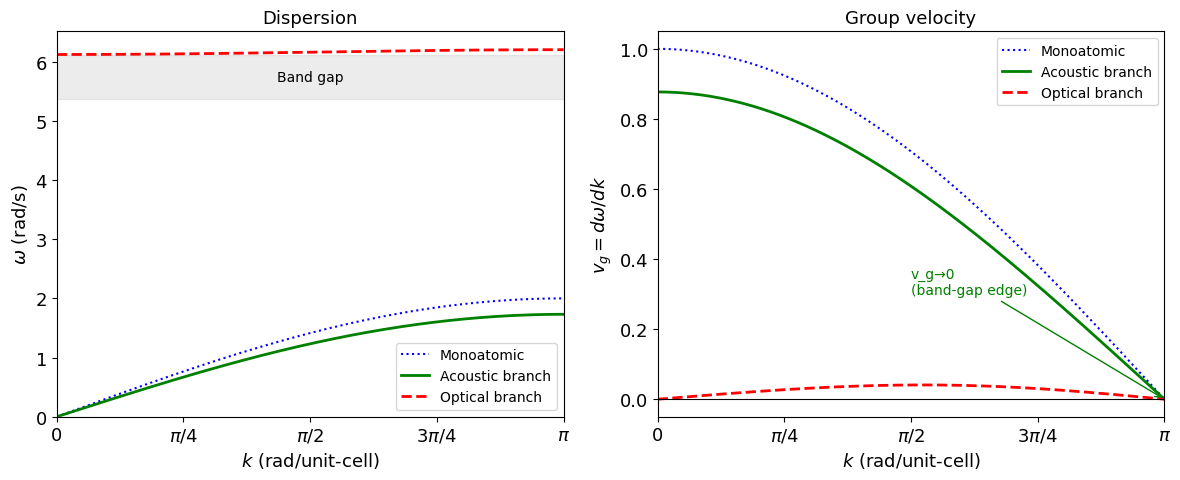

Long-wave sound speed (analytical): √(K/mx) = 1.0000
Group velocity at k→0 (numerical) : 0.8771


In [7]:
om_lo, om_hi = mass_in_mass_dispersion(k_vals, K, mx, my, k_int_eff)
vg_mono      = group_velocity(k_vals, monoatomic_dispersion(k_vals, K, mx))
vg_lower     = group_velocity(k_vals, om_lo)
vg_upper     = group_velocity(k_vals, om_hi)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: dispersion ---
ax = axes[0]
ax.plot(k_vals, monoatomic_dispersion(k_vals, K, mx), 'b:',  lw=1.5, label='Monoatomic')
ax.plot(k_vals, om_lo, 'g-',  lw=2, label='Acoustic branch')
ax.plot(k_vals, om_hi, 'r--', lw=2, label='Optical branch')
ax.axhspan(gap_lo, gap_hi, color='gray', alpha=0.15)
ax.text(np.pi/2, (gap_lo+gap_hi)/2, 'Band gap', ha='center', va='center', fontsize=10)
ax.set_xlabel(r'$k$ (rad/unit-cell)', fontsize=FS)
ax.set_ylabel(r'$\omega$ (rad/s)', fontsize=FS)
ax.set_title('Dispersion', fontsize=FS)
ax.set_xlim(0, np.pi)
ax.set_ylim(0, None)
ax.xaxis.set_ticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
ax.xaxis.set_ticklabels(['0', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$'])
ax.legend(fontsize=10)

# --- Right: group velocity ---
ax = axes[1]
ax.plot(k_vals, vg_mono,  'b:',  lw=1.5, label='Monoatomic')
ax.plot(k_vals, vg_lower, 'g-',  lw=2,   label='Acoustic branch')
ax.plot(k_vals, vg_upper, 'r--', lw=2,   label='Optical branch')
ax.axhline(0, color='black', lw=0.8)
ax.annotate('v_g→0\n(band-gap edge)', xy=(k_vals[np.argmin(np.abs(om_lo - gap_lo))], 0),
            xytext=(np.pi/2, 0.3), fontsize=10, color='green',
            arrowprops=dict(arrowstyle='->', color='green'))
ax.set_xlabel(r'$k$ (rad/unit-cell)', fontsize=FS)
ax.set_ylabel(r'$v_g = d\omega/dk$', fontsize=FS)
ax.set_title('Group velocity', fontsize=FS)
ax.set_xlim(0, np.pi)
ax.xaxis.set_ticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
ax.xaxis.set_ticklabels(['0', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$'])
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

v0 = float(np.sqrt(K / mx))
print(f'Long-wave sound speed (analytical): √(K/mx) = {v0:.4f}')
print(f'Group velocity at k→0 (numerical) : {vg_lower[1]:.4f}')

---
## Summary

| Quantity | Formula | Physical meaning |
|----------|---------|------------------|
| Monoatomic dispersion | ω = 2√(K/mx)\|sin(k/2)\| | One branch, no gap |
| Bloch stiffness | K_b(k) = 2K(1−cos k) | Effective coupling at wavenumber k |
| Mass-in-mass branches | mx·my·ω⁴ − B·ω² + C = 0 | Two branches, gap in between |
| Internal resonance | ω_res = √(k_int/my) | Lower band-gap edge |
| Upper gap edge | ω_hi = √(k_int(mx+my)/(mx·my)) | In-phase resonance of mx+my |
| Effective spring | k_int_eff = my·ω₀² | Impact → equivalent linear spring |
| Flat band | ω = const for all k | Localized (non-propagating) mode |
| Band gap | (ω_res, ω_hi) | Forbidden propagation range |
| Group velocity | v_g = dω/dk | Energy transport speed |
| v_g at k=0 | √(K/mx) | Long-wave (acoustic) speed |
| v_g at band edge | → 0 | Standing wave, full reflection |

**Take-away for your PINN results:**
- Bright flat stripes in S(k,ω) → local resonances driven by impacts
- Dark horizontal bands between stripes → band gaps (no propagation)
- Sloped (dispersive) bright region at low ω → acoustic branch
- Estimate k_int_eff from the lowest flat-band frequency, then overlay the analytical mass-in-mass branches to see how well the linear model fits the nonlinear PINN spectrum